# SEACOFS eddy velocity overlay

Plot rotated SEACOFS surface velocity from the source `outer_avg_*.nc` files and overlay the processed ESP/DOPPIO eddy centres, IDs, polarity, and fitted maximum-tangential-velocity contours.

In [1]:
from pathlib import Path
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from seacofs_eddy_dataset.config import load_config
from seacofs_eddy_dataset.core.grid import read_reference_grid
from seacofs_eddy_dataset.core.velocity import rotate_uv
from seacofs_eddy_dataset.stages.detection import find_model_files, reference_grid_path


## Load configuration and processed eddies

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
config = load_config(CONFIG_PATH)

grid = read_reference_grid(reference_grid_path(config))
DATA_PATH = config.output_root / "processed" / "eddy_dataset_processed.parquet"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Day", "Eddy"]).reset_index(drop=True)
print(f"Loaded {len(df):,} eddy-day rows ({df.Eddy.nunique():,} eddies).")
print(f"Coverage: {df.Date.min():%Y-%m-%d} to {df.Date.max():%Y-%m-%d}")
df.head()


Loaded 127,426 eddy-day rows (2,982 eddies).
Coverage: 1994-01-02 to 2019-02-28


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,1.758660,-0.532719,0.737370,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,2,1462,AE,151.793573,-37.940740,140,40,367.413413,196.922965,0.000038,...,1.074127,-0.351229,1.075196,61.057071,-32.946622,1.403926,39.348633,32,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,3,1462,CE,154.532063,-37.840699,199,59,593.967374,289.907485,-0.000029,...,1.067240,-0.222834,0.987632,48.830320,17.006777,1.251057,37.090402,29,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,4,1462,CE,151.533095,-36.945467,119,59,311.739045,292.852057,-0.000054,...,1.174796,0.459512,1.095028,53.495781,40.636482,1.539263,29.840039,36,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,5,1462,CE,157.811610,-37.957887,252,77,875.306477,377.288736,-0.000017,...,0.571531,0.263268,1.881171,48.572942,8.039906,1.926498,34.102079,32,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


## Source-file helpers

Pass an integer pipeline `Day` or a date such as `"2018-04-01"`. The notebook first uses `fname` from the processed table, then falls back to scanning model-file `ocean_time` values.

In [3]:
_DAY_FILE_CACHE = None


def _normalise_day(day_or_date, df_data):
    if isinstance(day_or_date, (int, np.integer)):
        day = int(day_or_date)
        dates = df_data.loc[df_data.Day.eq(day), "Date"]
        date = pd.Timestamp(dates.iloc[0]).normalize() if not dates.empty else None
    else:
        date = pd.Timestamp(day_or_date).normalize()
        days = df_data.loc[df_data.Date.dt.normalize().eq(date), "Day"]
        if days.empty:
            raise KeyError(f"Date {date:%Y-%m-%d} is absent from the processed dataset.")
        day = int(days.iloc[0])
    return day, date


def _day_file_map():
    global _DAY_FILE_CACHE
    if _DAY_FILE_CACHE is not None:
        return _DAY_FILE_CACHE
    mapping = {}
    for path in find_model_files(config):
        with nc.Dataset(path) as dataset:
            days = np.asarray(dataset.variables["ocean_time"][:].data, dtype=float) / 86400
        for value in days:
            mapping[int(round(value))] = path
    _DAY_FILE_CACHE = mapping
    return mapping


def _resolve_source_file(df_day, day):
    if "fname" in df_day:
        for value in df_day.fname.dropna().unique():
            path = Path(str(value)).expanduser()
            candidates = [path]
            if not path.is_absolute():
                candidates.append(config.model_root / path)
                candidates.append(config.model_root / path.name)
            for candidate in candidates:
                if candidate.exists():
                    return candidate
    mapping = _day_file_map()
    if day in mapping:
        return mapping[day]
    raise FileNotFoundError(f"Could not find an outer_avg source file containing Day {day}.")


def _time_index(dataset, day):
    days = np.rint(np.asarray(dataset.variables["ocean_time"][:].data, dtype=float) / 86400).astype(int)
    matches = np.flatnonzero(days == int(day))
    if matches.size != 1:
        raise KeyError(f"Expected one Day {day} time in source file; found {matches.size}.")
    return int(matches[0])


def _load_surface_velocity(source_file, day):
    with nc.Dataset(source_file) as dataset:
        t = _time_index(dataset, day)
        u = dataset["u_eastward"][t, -1, :, :].T
        v = dataset["v_northward"][t, -1, :, :].T
    return rotate_uv(u, v, grid.angle)


## Plotting function

In [12]:
def day_plot(day_or_date, df_data=df, *, num_label=True, show_quiver=True, quiver_step=12, speed_vmax=None, figsize=(9, 10), width=0.0015):
    """Overlay processed SEACOFS eddies on rotated surface velocity."""
    day, date = _normalise_day(day_or_date, df_data)
    df_day = df_data.loc[df_data.Day.eq(day)].copy()
    source_file = _resolve_source_file(df_day, day)
    u, v = _load_surface_velocity(source_file, day)
    speed = np.hypot(u, v)
    speed_vmax = float(np.nanpercentile(speed, 99)) if speed_vmax is None else speed_vmax

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    image = ax.pcolormesh(grid.X_grid, grid.Y_grid, speed, shading="auto", vmin=0, vmax=speed_vmax, cmap="Blues_r")
    fig.colorbar(image, ax=ax, label=r"Rotated surface current speed (m s$^{-1}$)", shrink=.7)

    if show_quiver:
        step = max(1, int(quiver_step))
        ax.quiver(grid.X_grid[::step, ::step], grid.Y_grid[::step, ::step], u[::step, ::step], v[::step, ::step], color="0.2", alpha=0.55, pivot="mid", width=width)

    colours = {"AE": "red", "CE": "cyan"}
    for row in df_day.itertuples(index=False):
        colour = colours.get(row.Cyc, "white")
        ax.scatter(row.xc, row.yc, color=colour, edgecolor="black", linewidth=0.8, s=20, zorder=10)
        if np.all(np.isfinite([row.q11, row.q12, row.q22, row.Rc])):
            Q = np.array([[row.q11, row.q12], [row.q12, row.q22]], dtype=float)
            dx, dy = grid.X_grid - row.xc, grid.Y_grid - row.yc
            rho2 = Q[0, 0] * dx**2 + 2 * Q[0, 1] * dx * dy + Q[1, 1] * dy**2
            ax.contour(grid.X_grid, grid.Y_grid, rho2, levels=[row.Rc**2 / 2], colors=[colour], linewidths=1.5, zorder=9)
        if num_label:
            ax.annotate(str(int(row.Eddy)), (row.xc, row.yc), textcoords="offset points", xytext=(3, 3), fontsize=8, color="white", weight="bold", path_effects=[pe.withStroke(linewidth=2, foreground="black")], zorder=11)

    if grid.lon_rho is not None and grid.lat_rho is not None:
        # lon_levels = np.arange(np.ceil(np.nanmin(grid.lon_rho) / 2) * 2, np.nanmax(grid.lon_rho), 5)
        # lat_levels = np.arange(np.ceil(np.nanmin(grid.lat_rho) / 2) * 2, np.nanmax(grid.lat_rho), 5)
        LEVELS_LAT = np.array([-40, -35, -30, -25])
        LEVELS_LON = np.array([150, 155, 160])
        lon_levels = LEVELS_LON
        lat_levels = LEVELS_LAT
        if lat_levels.size:
            c = ax.contour(grid.X_grid, grid.Y_grid, grid.lat_rho, levels=lat_levels, colors="black", linewidths=0.5, alpha=0.7)
            ax.clabel(c, fmt=lambda value: f"{abs(value):.0f}°S", fontsize=8)
        if lon_levels.size:
            c = ax.contour(grid.X_grid, grid.Y_grid, grid.lon_rho, levels=lon_levels, colors="black", linewidths=0.5, alpha=0.7)
            ax.clabel(c, fmt=lambda value: f"{value:.0f}°E", fontsize=8)

    ae_count, ce_count = int(df_day.Cyc.eq("AE").sum()), int(df_day.Cyc.eq("CE").sum())
    title_date = f" | {date:%Y-%m-%d}" if date is not None else ""
    ax.set(title=f"SEACOFS eddies | Day {day}{title_date} | AE={ae_count}, CE={ce_count}", xlabel="x (km)", ylabel="y (km)", xlim=(grid.x_grid.min(), grid.x_grid.max()), ylim=(grid.y_grid.min(), grid.y_grid.max()), aspect="equal")
    print(f"Source: {source_file}")
    print(f"Plotted {len(df_day)} eddies: {ae_count} AEs and {ce_count} CEs")
    return fig, ax, df_day


## Plot a day

The default selects the day containing the most processed eddies. Replace `DAY` with another integer or date string.

Source: /srv/scratch/z3533156/26year_BRAN2020/outer_avg_07911.nc
Plotted 30 eddies: 15 AEs and 15 CEs


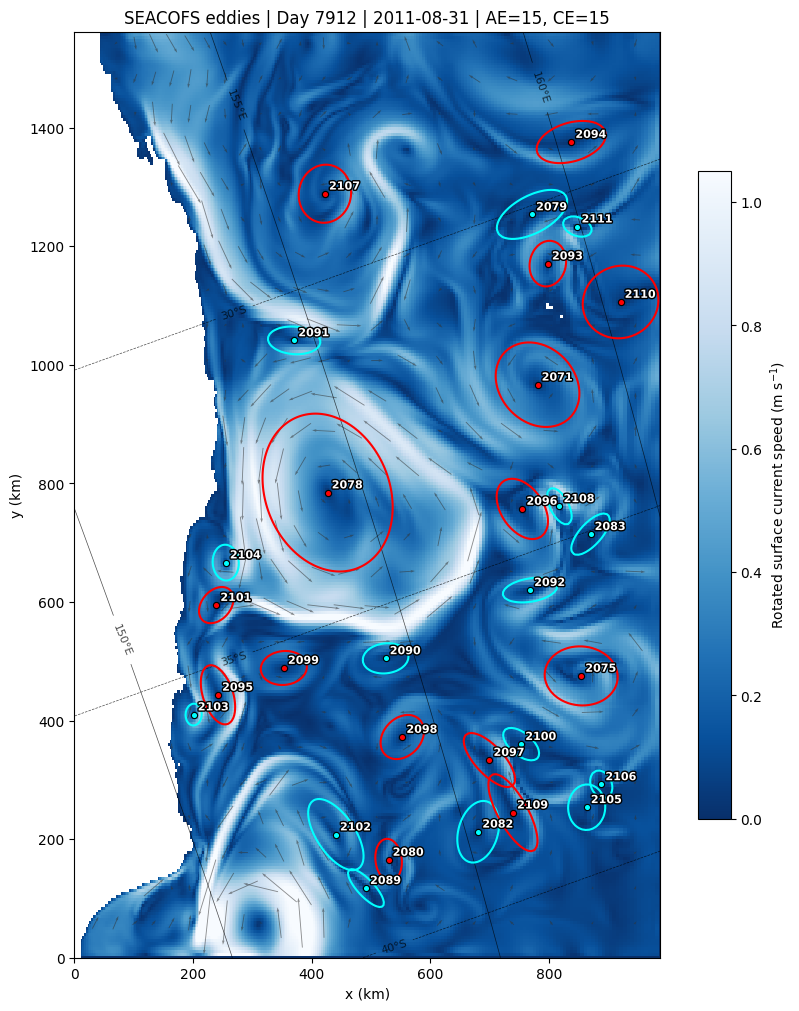

In [13]:
DAY = int(df.groupby("Day").size().idxmax())
# DAY = "2018-04-01"

fig, ax, df_day = day_plot(DAY, num_label=True, show_quiver=True, quiver_step=12, width=0.0015)


## Inspect plotted eddies

In [6]:
df_day[["Eddy", "Day", "Date", "Cyc", "lon", "lat", "R", "Rc", "Omega"]]


,Eddy,Day,Date,Cyc,lon,lat,R,Rc,Omega
89613,2071,7912,2011-08-31,AE,158.512372,-32.618141,61.270431,99.315243,0.000009
89614,2075,7912,2011-08-31,AE,157.866140,-37.053558,33.258595,79.469113,0.000014
89615,2078,7912,2011-08-31,AE,154.383250,-33.084658,90.224960,169.474152,0.000009
89616,2079,7912,2011-08-31,CE,159.251860,-30.131506,28.872516,66.980206,-0.000004
89617,2080,7912,2011-08-31,AE,153.439989,-38.715851,16.728540,43.468807,0.000006
89618,2082,7912,2011-08-31,CE,155.230504,-38.773775,43.488359,59.737730,-0.000006
89619,2083,7912,2011-08-31,CE,158.704011,-35.052513,32.289721,40.597859,-0.000004
89620,2089,7912,2011-08-31,CE,152.868418,-39.006776,20.318074,35.039934,-0.000008
89621,2090,7912,2011-08-31,CE,154.484097,-35.783103,27.543795,44.934331,-0.000009
89622,2091,7912,2011-08-31,CE,154.658133,-30.712971,34.367457,45.770693,-0.000014


## Optional sequence

In [7]:
# for day in sorted(df.Day.unique())[:3]:
#     day_plot(int(day), num_label=False, quiver_step=16)
#     plt.show()
